In [ ]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 2. Upload dataset
df=pd.read_csv('/content/1776250375-P2-Healthcare Analytics for Doctor Visits.csv')

In [4]:
# 4. Check dataset
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.info()

Shape: (5190, 13)

Columns:
['Unnamed: 0', 'visits', 'gender', 'age', 'income', 'illness', 'reduced', 'health', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB


In [5]:
# 5. Missing values
df.isnull().sum()

,0
Unnamed: 0,0
visits,0
gender,0
age,0
income,0
illness,0
reduced,0
health,0
private,0
freepoor,0


In [6]:
# 6. Descriptive statistics
df.describe()

,Unnamed: 0,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,2595.500000,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,1498.368279,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,1.000000,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,1298.250000,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,2595.500000,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,3892.750000,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,5190.000000,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


In [7]:
# 7. Visits statistics
print("Mean visits:", df["visits"].mean())
print("Median visits:", df["visits"].median())
print("Standard deviation:", df["visits"].std())
print("Minimum visits:", df["visits"].min())
print("Maximum visits:", df["visits"].max())

Mean visits: 0.3017341040462428
Median visits: 0.0
Standard deviation: 0.7981338314137587
Minimum visits: 0
Maximum visits: 9


In [8]:
# 8. Gender distribution
print(df["gender"].value_counts())
print(df["gender"].value_counts(normalize=True) * 100)

gender
female    2702
male      2488
Name: count, dtype: int64
gender
female    52.061657
male      47.938343
Name: proportion, dtype: float64


In [9]:
# 9. Visits by gender
df.groupby("gender")["visits"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
gender,,,,,,
female,2702,0.361954,0.0,0.857920,0,8
male,2488,0.236334,0.0,0.722168,0,9


In [10]:
# 10. Age statistics
print("Mean age:", df["age"].mean())
print("Median age:", df["age"].median())
print("Minimum age:", df["age"].min())
print("Maximum age:", df["age"].max())

Mean age: 0.40638535645472057
Median age: 0.32
Minimum age: 0.19
Maximum age: 0.72


In [11]:
# 11. Visits by age
df.groupby("age")["visits"].mean().sort_values(ascending=False)

,visits
age,
0.72,0.482968
0.52,0.414414
0.57,0.399267
0.67,0.377778
0.62,0.354430
0.42,0.317460
0.47,0.270718
0.27,0.258126
0.37,0.246575


In [12]:
# 12. Income vs visits
print(df[["income", "visits"]].corr())

         income   visits
income  1.00000 -0.07684
visits -0.07684  1.00000


In [13]:
# 13. Age vs visits correlation
print("Age-Visits correlation:",
      df["age"].corr(df["visits"]))

Age-Visits correlation: 0.1245367613437179


In [14]:
# 14. Income vs visits correlation
print("Income-Visits correlation:",
      df["income"].corr(df["visits"]))

Income-Visits correlation: -0.07683982934758851


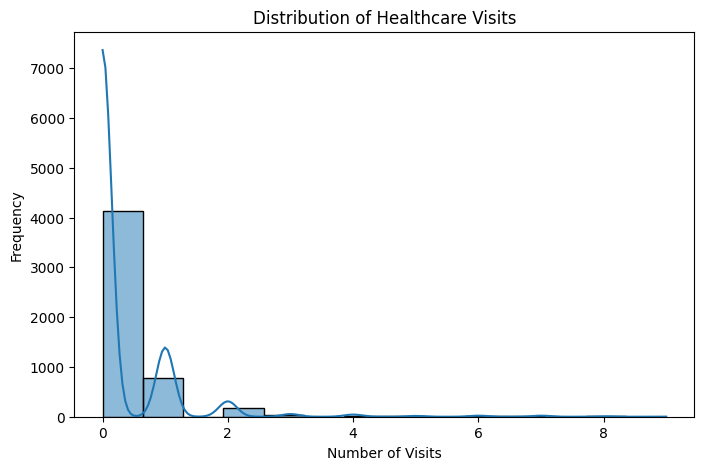

In [15]:
# 15. Distribution of visits
plt.figure(figsize=(8,5))
sns.histplot(df["visits"], kde=True)
plt.xlabel("Number of Visits")
plt.ylabel("Frequency")
plt.title("Distribution of Healthcare Visits")
plt.show()

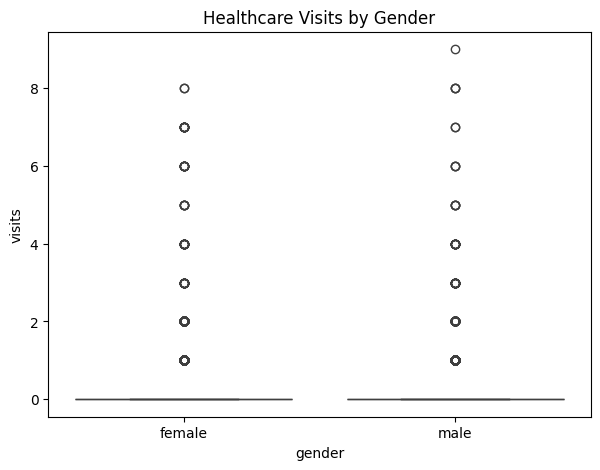

In [16]:
# 16. Gender vs visits
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="gender", y="visits")
plt.title("Healthcare Visits by Gender")
plt.show()

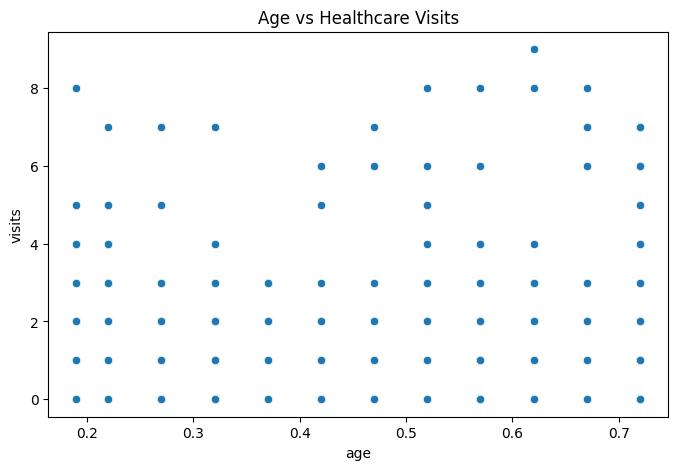

In [17]:
# 17. Age vs visits
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="age", y="visits")
plt.title("Age vs Healthcare Visits")
plt.show()

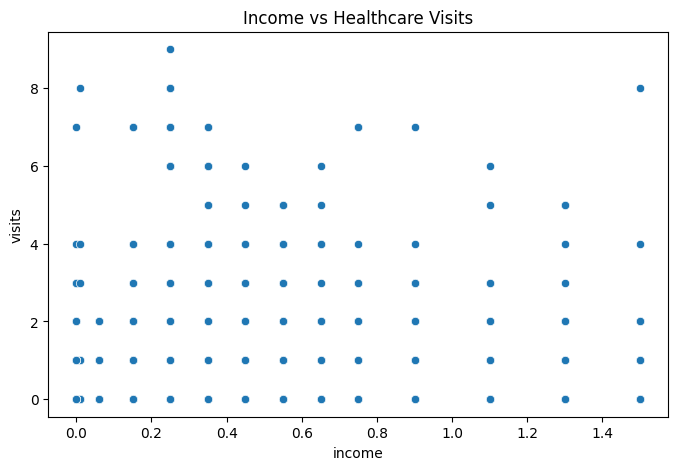

In [18]:
# 18. Income vs visits
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="income", y="visits")
plt.title("Income vs Healthcare Visits")
plt.show()

In [19]:
# 19. IQR and outlier detection
Q1 = df["visits"].quantile(0.25)
Q3 = df["visits"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower bound: 0.0
Upper bound: 0.0


In [20]:
# 20. Identify outliers
outliers = df[
    (df["visits"] < lower_bound) |
    (df["visits"] > upper_bound)
]

print("Number of outliers:", len(outliers))
outliers.head()

Number of outliers: 1049


,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [21]:
# Average visits by health status
df.groupby("health")["visits"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
health,,,,,,
0,3026,0.199273,0.0,0.593307,0,8
1,823,0.335358,0.0,0.787247,0,8
2,446,0.381166,0.0,0.878203,0,7
3,273,0.417582,0.0,0.951770,0,7
4,187,0.534759,0.0,1.258357,0,8
5,132,0.530303,0.0,1.225925,0,8
6,104,0.625000,0.0,1.142196,0,7
7,61,0.918033,0.0,1.486552,0,8
8,42,0.476190,0.0,0.862161,0,4


In [22]:
df.groupby("private")["visits"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
private,,,,,,
no,2892,0.307400,0.0,0.818271,0,9
yes,2298,0.294604,0.0,0.772163,0,8


In [24]:
df.groupby("freerepat")["visits"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
freerepat,,,,,,
no,4099,0.257868,0.0,0.743022,0,8
yes,1091,0.466544,0.0,0.960470,0,9


In [25]:
# Number of people with/without chronic conditions
print(df["nchronic"].value_counts())
print(df["lchronic"].value_counts())

nchronic
no     3098
yes    2092
Name: count, dtype: int64
lchronic
no     4585
yes     605
Name: count, dtype: int64


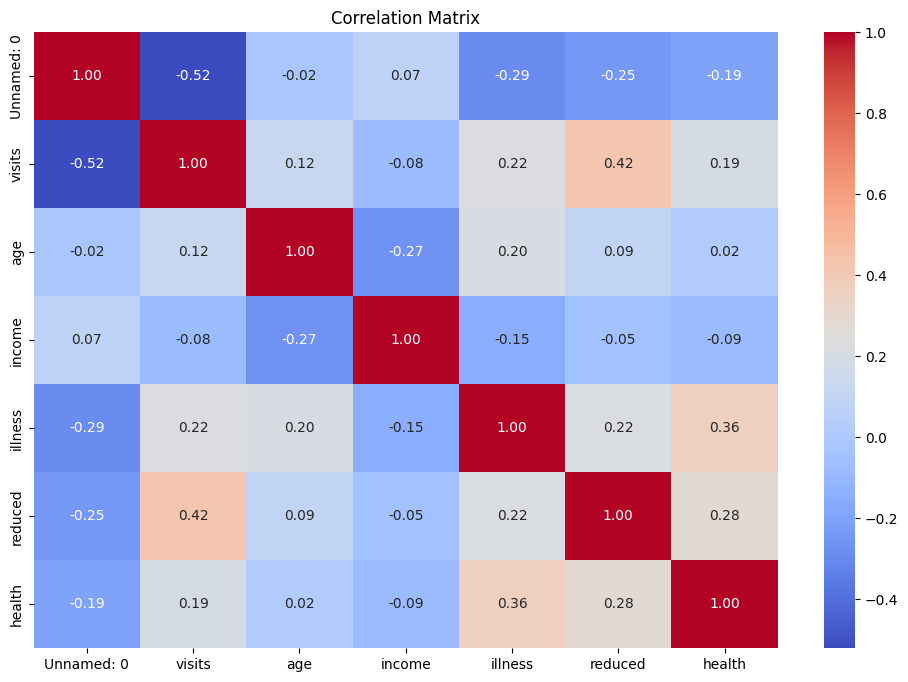

In [27]:
plt.figure(figsize=(12, 8))

correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [28]:
summary = pd.DataFrame({
    "Mean": df.mean(numeric_only=True),
    "Median": df.median(numeric_only=True),
    "Std Dev": df.std(numeric_only=True),
    "Minimum": df.min(numeric_only=True),
    "Maximum": df.max(numeric_only=True)
})

summary

,Mean,Median,Std Dev,Minimum,Maximum
Unnamed: 0,2595.500000,2595.50,1498.368279,1.00,5190.00
visits,0.301734,0.00,0.798134,0.00,9.00
age,0.406385,0.32,0.204782,0.19,0.72
income,0.583160,0.55,0.368907,0.00,1.50
illness,1.431985,1.00,1.384152,0.00,5.00
reduced,0.861850,0.00,2.887628,0.00,14.00
health,1.217534,0.00,2.124266,0.00,12.00


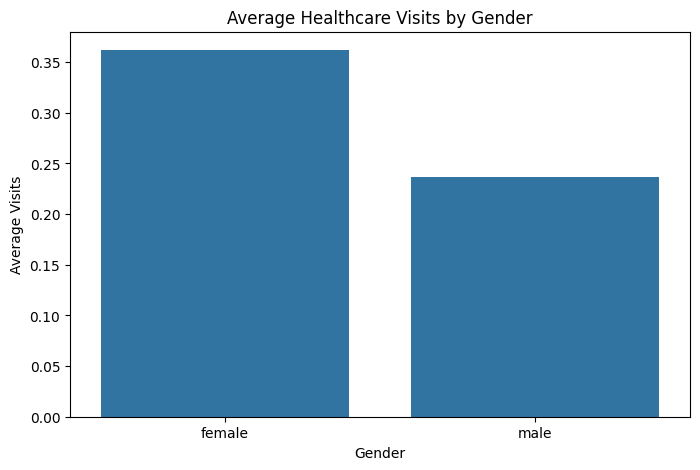

In [29]:
gender_visits = df.groupby("gender")["visits"].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=gender_visits, x="gender", y="visits")
plt.title("Average Healthcare Visits by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Visits")
plt.show()

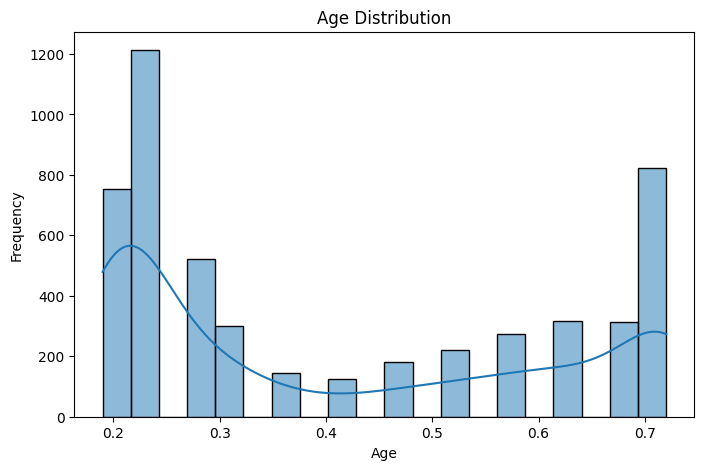

In [30]:
plt.figure(figsize=(8, 5))
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

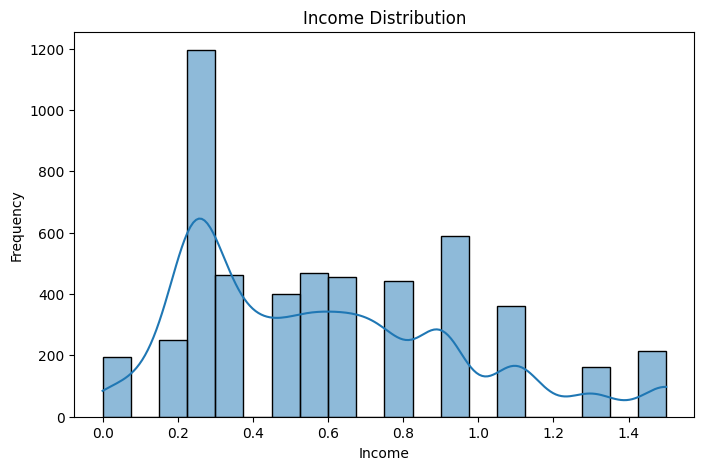

In [31]:
plt.figure(figsize=(8, 5))
sns.histplot(df["income"], bins=20, kde=True)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

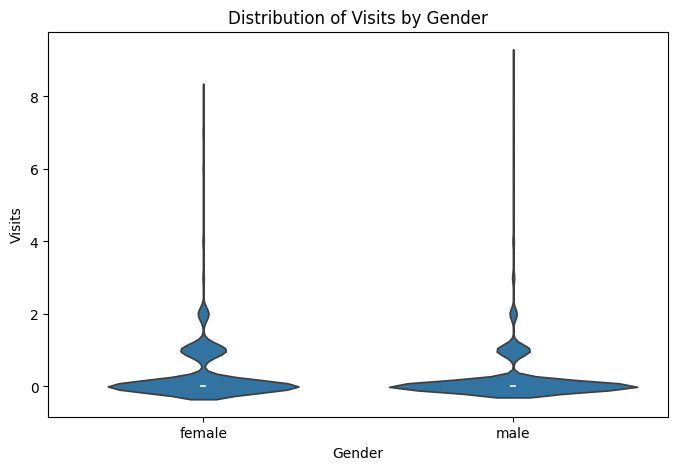

In [32]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x="gender", y="visits")
plt.title("Distribution of Visits by Gender")
plt.xlabel("Gender")
plt.ylabel("Visits")
plt.show()

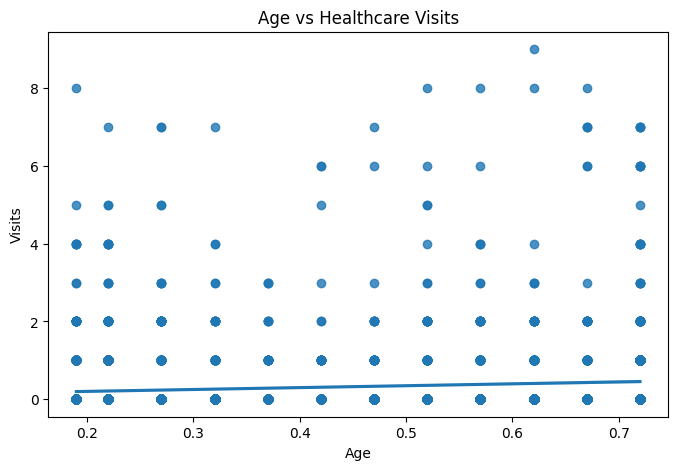

In [33]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="age", y="visits")
plt.title("Age vs Healthcare Visits")
plt.xlabel("Age")
plt.ylabel("Visits")
plt.show()

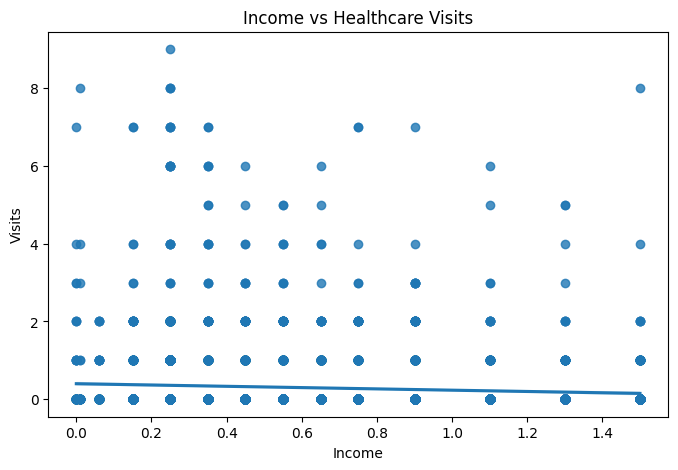

In [34]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="income", y="visits")
plt.title("Income vs Healthcare Visits")
plt.xlabel("Income")
plt.ylabel("Visits")
plt.show()

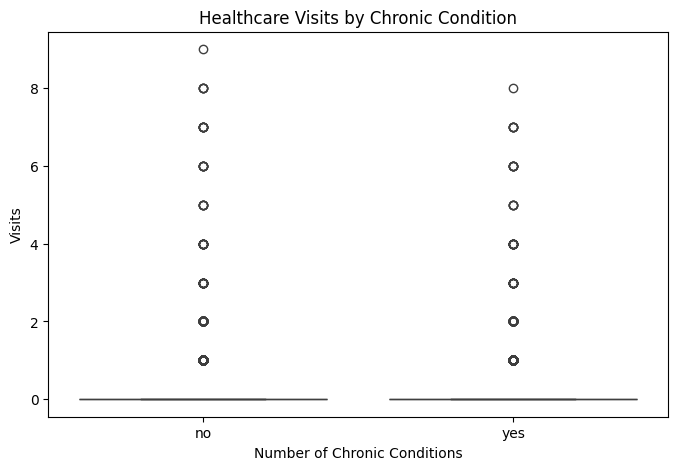

In [35]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="nchronic", y="visits")
plt.title("Healthcare Visits by Chronic Condition")
plt.xlabel("Number of Chronic Conditions")
plt.ylabel("Visits")
plt.show()

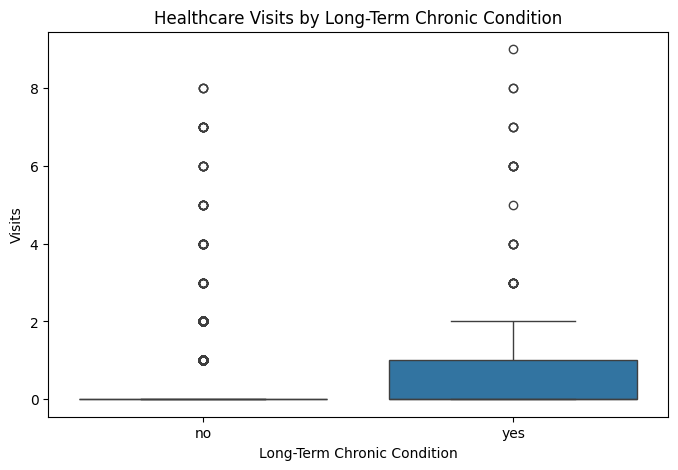

In [36]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="lchronic", y="visits")
plt.title("Healthcare Visits by Long-Term Chronic Condition")
plt.xlabel("Long-Term Chronic Condition")
plt.ylabel("Visits")
plt.show()

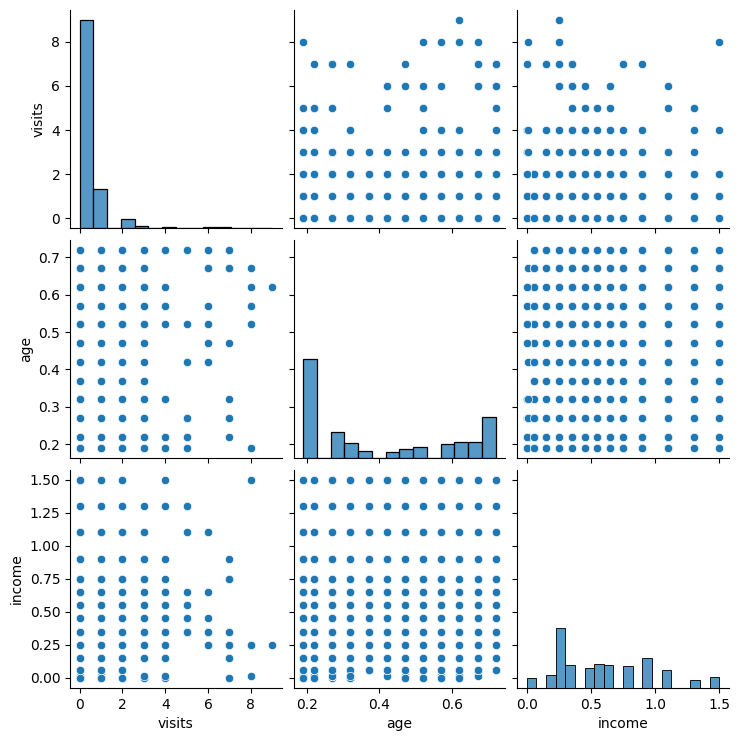

In [38]:
selected_cols = [
    "visits",
    "age",
    "income",
    "nchronic"
]

sns.pairplot(
    df[selected_cols],
    diag_kind="hist"
)

plt.show()

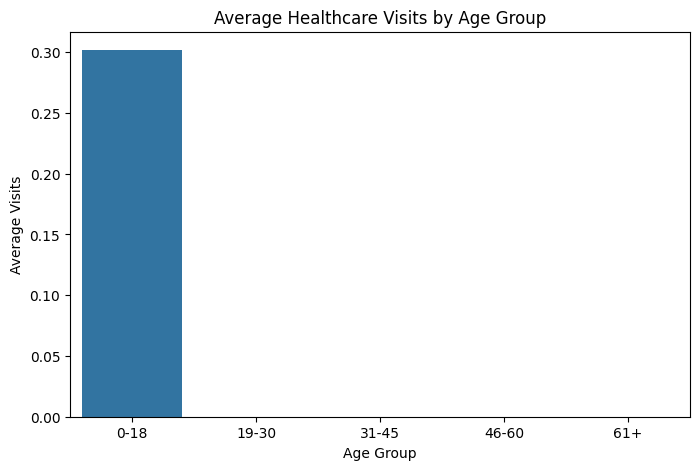

In [39]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 18, 30, 45, 60, 100],
    labels=["0-18", "19-30", "31-45", "46-60", "61+"]
)

age_group_visits = (
    df.groupby("age_group", observed=True)["visits"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=age_group_visits,
    x="age_group",
    y="visits"
)

plt.title("Average Healthcare Visits by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Visits")
plt.show()

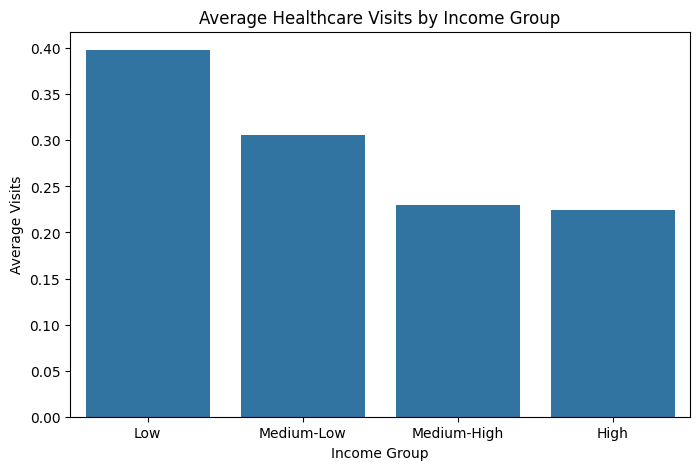

In [40]:
df["income_group"] = pd.qcut(
    df["income"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

income_group_visits = (
    df.groupby("income_group", observed=True)["visits"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=income_group_visits,
    x="income_group",
    y="visits"
)

plt.title("Average Healthcare Visits by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Average Visits")
plt.show()

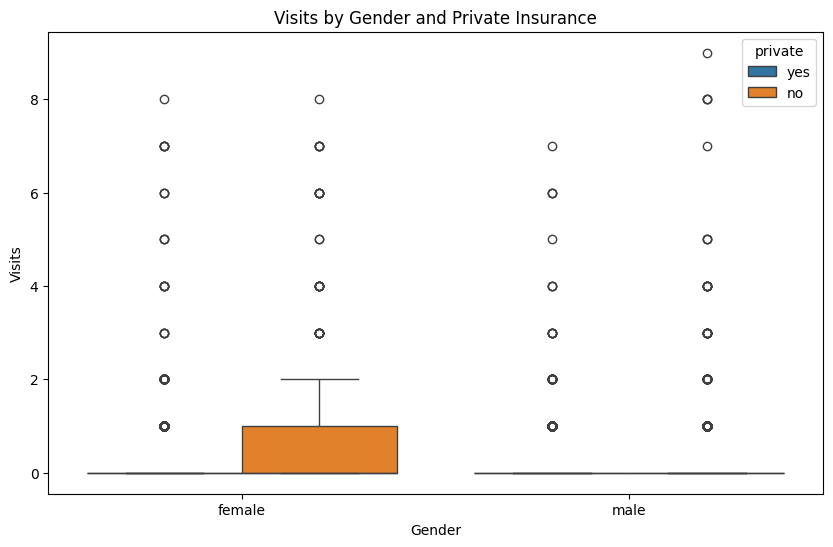

In [41]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="gender",
    y="visits",
    hue="private"
)

plt.title("Visits by Gender and Private Insurance")
plt.xlabel("Gender")
plt.ylabel("Visits")
plt.show()

Question 1:
How does the number of doctor visits vary across different gender groups?

Analysis:

The dataset was grouped by gender to calculate the number of observations and the average, median and standard deviation of visits. Boxplots and bar plots can be used to compare the distribution and average number of doctor visits between male and female patients.

Visualization:

Doctor Visits by Gender – Boxplot
Average Doctor Visits by Gender – Bar Plot
Gender Distribution – Count Plot
Interpretation:

The analysis allows comparison of healthcare utilization between gender groups. Differences in the average or distribution of doctor visits indicate that healthcare-use patterns may vary between the groups represented in the dataset.

Limitation:

The analysis identifies an association between gender and doctor visits. It does not establish that gender itself causes differences in healthcare utilization. Age, illness, health status, income and chronic conditions may also influence the number of visits.

Question 2:
Is there a relationship between age and the number of doctor visits?

Analysis:

A scatter plot was created using age on the x-axis and visits on the y-axis. Correlation analysis can also be used to measure the linear association between age and doctor visits.

Visualization:

Age vs Doctor Visits – Scatter Plot
Age vs Doctor Visits – Regression Plot
Doctor Visits by Age Group – Bar Plot
Interpretation:

The analysis helps examine whether doctor-visit frequency changes across different age levels. The scatter plot can reveal whether the relationship appears weak, strong or highly variable.

Limitation:

Age alone cannot explain healthcare utilization. Illness, health status, chronic conditions, income and other characteristics may also affect the number of visits.

Question 3:
Is there a relationship between income and the number of doctor visits?

Analysis:

The variables income and visits were examined using a scatter plot and correlation analysis. Income groups can also be created to compare average doctor visits across different income levels.

Visualization:

Income vs Doctor Visits – Scatter Plot
Income vs Doctor Visits – Regression Plot
Average Doctor Visits by Income Group – Bar Plot
Interpretation:

The analysis provides a way to examine whether healthcare utilization varies across different income levels. Differences in average visits between income groups may indicate differences in healthcare-use patterns.

Limitation:

The analysis does not establish that income directly causes differences in doctor visits. Insurance coverage, illness, health status and chronic conditions may also influence healthcare utilization.

Question 4:
How does illness level relate to the number of doctor visits?

Analysis:

The dataset was grouped by illness to compare the number of doctor visits across different illness levels. Average, median and distribution of visits can be examined for each illness category.

Visualization:

Illness vs Doctor Visits – Boxplot
Average Visits by Illness Level – Bar Plot
Illness Distribution – Count Plot
Interpretation:

The analysis helps examine whether people with different illness levels show different patterns of healthcare utilization. A comparison of average visits and distributions provides information about the association between illness and doctor visits.

Limitation:

The analysis does not establish that illness level alone determines the number of visits. Other variables such as age, health status and chronic conditions may contribute to the observed differences.

Question 5:How does health status affect doctor visits?

Analysis:

The health variable was compared with visits using grouped descriptive statistics and boxplots. Average and median visits can be calculated for each health-status category.

Visualization:

Health Status vs Doctor Visits – Boxplot
Average Visits by Health Status – Bar Plot
Health Status Distribution – Count Plot
Interpretation:

The analysis helps identify differences in healthcare utilization across health-status categories. The distribution of visits can show whether some health-status groups have greater variation in doctor visits.

Limitation:

The analysis identifies association rather than causation. Health status may be related to illness, age and chronic conditions, which can also influence doctor visits.

Question 6:
Is there a relationship between chronic conditions and doctor visits?

Analysis:

The variables nchronic and lchronic were examined in relation to visits. Grouped statistics and boxplots can be used to compare healthcare utilization among patients with different chronic-condition profiles.

Visualization:

Number of Chronic Conditions vs Visits – Boxplot
Long-Term Chronic Condition vs Visits – Boxplot
Average Visits by Chronic Condition – Bar Plot
Interpretation:

The analysis helps examine whether healthcare utilization differs according to chronic-condition status. Comparing average visits across chronic-condition categories provides a useful view of healthcare-use patterns.

Limitation:

The analysis cannot establish that chronic conditions alone cause higher or lower doctor visits. Age, illness, health status and other factors may also contribute.

Question 7:
Does private health insurance status relate to doctor visits?

Analysis:

The private variable was compared with visits using grouped statistics and boxplots. Average and median doctor visits can be calculated separately for patients with and without private insurance.

Visualization:

Private Insurance vs Doctor Visits – Boxplot
Average Visits by Private Insurance – Bar Plot
Private Insurance Distribution – Count Plot
Interpretation:

The analysis allows comparison of healthcare utilization between patients with different private-insurance statuses. Differences in visit frequency can indicate different healthcare-use patterns between the groups.

Limitation:

Insurance status is only one factor associated with healthcare utilization. Income, illness, age, health status and chronic conditions may also affect visits.

Question 8:
How does healthcare utilization vary according to free healthcare coverage?

Analysis:

The variables freepoor and freerepat were compared with visits. Grouped statistics and visualizations can be used to examine differences in doctor visits across these coverage categories.

Visualization:

Free-Poor Coverage vs Visits – Boxplot
Free-Repat Coverage vs Visits – Boxplot
Average Visits by Coverage Status – Bar Plot
Interpretation:

The analysis provides a comparison of healthcare utilization across different coverage categories. It helps identify whether the distribution or average number of visits differs between groups.

Limitation:

The analysis identifies differences between coverage groups but does not establish that coverage status itself causes those differences. Patient characteristics and health conditions may also influence utilization.

Question 9:
How are age, income and illness related to doctor visits?

Analysis:

A multivariate analysis was performed using numeric variables such as visits, age, income, illness, reduced, health and nchronic. A correlation matrix and pair plot can be used to examine relationships among these variables.

Visualization:

Correlation Heatmap
Pair Plot
Age vs Visits – Scatter Plot
Income vs Visits – Scatter Plot
Interpretation:

The multivariate analysis provides a broader view of healthcare utilization. It allows relationships between demographic, socioeconomic and health-related variables to be examined together rather than considering each variable independently.

Limitation:

Correlation does not establish causation. Relationships between variables may also be affected by other variables in the dataset.

Question 10:
Are there unusually high or low numbers of doctor visits?

Analysis:

IQR-based outlier detection was applied to visits. The first quartile (Q1), third quartile (Q3), interquartile range (IQR), lower bound and upper bound were calculated.

Visualization:

Doctor Visits – Boxplot
Doctor Visits Distribution – Histogram
Doctor Visits – KDE/Histogram
Interpretation:

The analysis can identify observations with unusually high or low numbers of doctor visits. These observations may represent patients with unusual healthcare-utilization patterns.

Limitation:

An outlier is not automatically an error. A high number of visits may represent genuine healthcare needs and should be investigated before removing any observation.

Conclusion

The Healthcare Doctor Visits Analysis provides a data-driven view of healthcare utilization using demographic, socioeconomic and health-related variables.

The analysis examines the number of doctor visits in relation to gender, age, income, illness, reduced activity, health status, insurance coverage and chronic conditions.

Descriptive statistics, grouped analysis, boxplots, bar plots, scatter plots, regression plots, histograms, correlation analysis and heatmaps can be used to identify patterns in healthcare utilization.

The analysis can help understand how doctor-visit patterns differ across demographic and health-related groups and how socioeconomic and healthcare-coverage variables are associated with utilization.

However, the results should be interpreted as associations rather than causal relationships. Doctor visits can be influenced by multiple factors simultaneously, including age, illness, health status, chronic conditions, income and healthcare coverage.